In [1]:
# Simple Stochastic Gradient Descent-Based Learning Engine
# Problem: Predict e^x with Maclaurin Series

In [2]:
import math
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Dataset for our toy model
# We will use eight weights and a bias for now
train_x = [i/100 for i in range(-100, 100)]
train_y = [math.exp(i/100) for i in range(-100, 100)]
test_x = [i/100 for i in range(100, 150)]
test_y = [math.exp(i/100) for i in range(100, 150)]

In [4]:
class SGDBLE:
    def __init__(self):
        random.seed(3141592) # So that we get the same result
        self.ws = [random.uniform(-1, 1) for _ in range(8)]
        self.b = random.random()
    
    def forward(self, x):
        self.ypred = sum(w * x**k for w, k in zip(self.ws,range(1, 9))) + self.b
        return self.ypred

    def loss(self, y, ypred):
        self.loss_val = 0.5 * (y - ypred)**2 # Let's use MSE
        return self.loss_val

    def grads(self, x, y, ypred):
        base_der = ypred - y # i.e. dL / dypred
        self.grads_w = [base_der * x**i for i in range(1, 9)]
        self.grad_b = base_der
        
    def update(self, lr):
        for i in range(8):
            self.ws[i] -= lr * self.grads_w[i]
        self.b -= lr * self.grad_b

    def train(self, epochs, lr):
        losses = []
        for epoch in range(epochs):
            loss_total = 0
            for i in range(len(train_x)):
                ypred = self.forward(train_x[i])
                loss_total += self.loss(train_y[i], ypred)
                self.grads(train_x[i], train_y[i], ypred)
                self.update(lr)
            loss_avg = loss_total / len(train_x)
            losses.append(loss_avg)

            if (epoch+1) % 100 == 0:
                print(f"Epoch: {epoch+1}/{epochs}, Loss: {loss_avg}")
            
        return losses

    def test(self):
        loss_total = 0
        for i in range(0, len(test_x), 2):
            ypred1 = self.forward(test_x[i])
            loss_total += self.loss(test_y[i], ypred1)

            if i + 1 < len(test_x):
                ypred2 = self.forward(test_x[i + 1])
                loss_total += self.loss(test_y[i + 1], ypred2)
    
                print(f"Test {i+1}                      Test {i+2}")
                print(f"y:     {test_y[i]}      y:     {test_y[i+1]}")
                print(f"ypred: {ypred1}     ypred: {ypred2}")
                print()
            else:
                print(f"Test {i+1}")
                print(f"y:     {test_y[i]}")
                print(f"ypred: {ypred1}")
    
        loss_total /= len(test_x)


    def print_params(self):
        coeff = [1 / math.factorial(i+1) for i in range(8)]
        for i in range(8):
            print(f"w{i+1}: {self.ws[i]}, Expected: {coeff[i]}")
        print(f"b: {self.b}, Expected: 1")

model = SGDBLE()

In [5]:
def graph_loss(losses):
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    
def graph_pred():
    xs = [i / 10 for i in range(-100, 200)]
    true = [math.exp(x) for x in xs]
    pred = [model.forward(x) for x in xs]

    plt.plot(xs, true, label="e^x")
    plt.plot(xs, pred, label="Prediction")
    plt.yscale("log")
    plt.legend()
    plt.show

Epoch: 100/1000, Loss: 0.00013234985876534958
Epoch: 200/1000, Loss: 3.427320321762344e-05
Epoch: 300/1000, Loss: 2.4492707827970274e-05
Epoch: 400/1000, Loss: 2.2669862503550263e-05
Epoch: 500/1000, Loss: 2.172205317266906e-05
Epoch: 600/1000, Loss: 2.0984248749352728e-05
Epoch: 700/1000, Loss: 2.036538265870468e-05
Epoch: 800/1000, Loss: 1.9834658817269138e-05
Epoch: 900/1000, Loss: 1.937270927247297e-05
Epoch: 1000/1000, Loss: 1.8965386261105253e-05


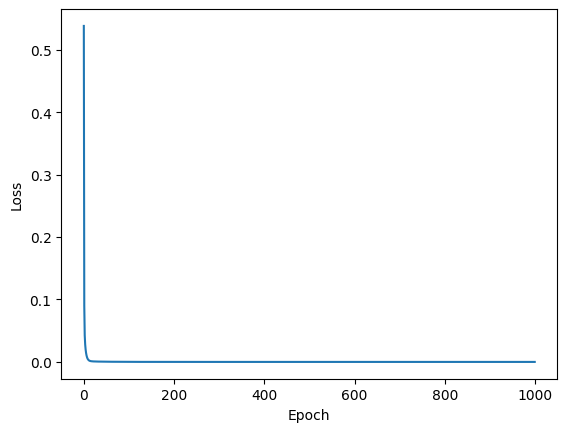

w1: 0.9444454598562942, Expected: 1.0
w2: 0.49986306356857685, Expected: 0.5
w3: 0.620431907367758, Expected: 0.16666666666666666
w4: 0.21618569290559692, Expected: 0.041666666666666664
w5: -0.9321256839917001, Expected: 0.008333333333333333
w6: -0.48709437200615985, Expected: 0.001388888888888889
w7: 0.5594822789317027, Expected: 0.0001984126984126984
w8: 0.33002989302732855, Expected: 2.48015873015873e-05
b: 0.9983077779493585, Expected: 1


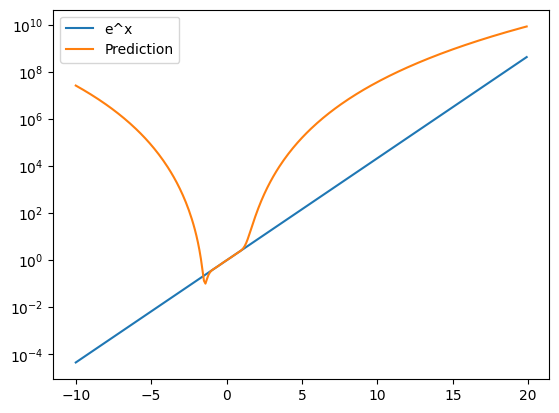

In [6]:
losses = model.train(1000, 0.005)
graph_loss(losses)
model.print_params()
graph_pred()

In [7]:
model.test()

Test 1                      Test 2
y:     2.718281828459045      y:     2.7456010150169163
ypred: 2.7495260176087557     ypred: 2.7867851769675642

Test 3                      Test 4
y:     2.7731947639642978      y:     2.801065834699079
ypred: 2.8257757734623574     ypred: 2.8666322590606814

Test 5                      Test 6
y:     2.82921701435156      y:     2.857651118063164
ypred: 2.909497162739583     ypred: 2.954521430346852

Test 7                      Test 8
y:     2.8863709892679585      y:     2.915379499976997
ypred: 3.001864774074873     ypred: 3.0516960317129964

Test 9                      Test 10
y:     2.944679551065524      y:     2.9742740725630656
ypred: 3.1041935358457007     ypred: 3.159545493165112

Test 11                      Test 12
y:     3.0041660239464334      y:     3.034358394435676
ypred: 3.2179503740678106     ypred: 3.2796173127071624

Test 13                      Test 14
y:     3.0648542032930024      y:     3.095656500124711
ypred: 3.3447665176737